In [5]:
import pandas as pd
import pickle   
from geoai.utils_geo.raster_ops import RasterOperations
from geoai.utils_ml.model_ops import ModelOperations
from geoai.utils_ds.visualize_ops import VisualizeOperations

model_ops = ModelOperations()
vis_ops = VisualizeOperations()
raster_ops = RasterOperations()

In [6]:
X_train = pd.read_csv("csv_files/X_train.csv")
X_test = pd.read_csv("csv_files/X_test.csv")
y_train = pd.read_csv("csv_files/y_train_encoded.csv")
y_test = pd.read_csv("csv_files/y_test_encoded.csv")
X_train.head()

,BLUE,GREEN,RED,NIR,SWIR
0,350.0,542.0000,323.0,3277.0000,1975.3334
1,390.0,555.0000,380.0,3016.6667,1991.0000
2,1177.0,1224.6666,1268.0,1385.0000,1687.4000
3,363.2,546.5000,395.0,3244.5000,2052.0000
4,1095.6,1107.3334,1154.0,1228.0000,1573.0000


In [12]:
# Subset the data to only include the bands used in fitting the model
rgbnir_train = X_train[["BLUE", "GREEN", "RED"]]
rgbnir_test = X_test[["BLUE", "GREEN", "RED"]]

In [13]:
# Load the simple model
with open("trained_models/simple_pipeline.pkl", "rb") as file:
    simple_model = pickle.load(file)
simple_model

Pipeline(steps=[('min_max_scaler', MinMaxScaler()),
                ('lr', LogisticRegression(max_iter=1000, random_state=1))])

In [14]:
# make predictions for train and test data
simple_preds_train = simple_model.predict(rgbnir_train)
simple_preds_test = simple_model.predict(rgbnir_test)

In [9]:
# compute for the train and test data the accuracy of the simple model
print("Simple Model Accuracy")
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, simple_preds_train)}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, simple_preds_test)}")


Simple Model Accuracy
Train Accuracy: (0.8630490956072352, 0.8637207792550923, 0.8630490956072352, 0.8633322989381884)
Test Accuracy: (0.8760330578512396, 0.8755063979536191, 0.8760330578512396, 0.8756870576139825)


# Types of Accuracy

## Accuracy 

<b><i>Defintion</b></i>: ratio of correctly predicted instances (both true positives and true negatives) to the total instances.

<b><i>Use Case</b></i>:
Best for balanced datasets where the number of positive and negative samples are roughly equal.
Not informative for imbalanced datasets as it can be misleading (e.g., high accuracy in a dataset where the majority class dominates).


## Precision 

<b><i>Defintion</b></i>: ratio of correctly predicted positive observations to the total predicted positives.

<b><i>Use Case</b></i>:
Useful in situations where the cost of false positives is high. Important in cases like spam detection, where you want to minimize the number of legitimate emails marked as spam.


## Recall 

<b><i>Defintion</b></i>: ratio of correctly predicted positive observations to all actual positives.

<b><i>Use Case</b></i>:
Useful in situations where the cost of false negatives is high. Important in cases like disease screening, where you want to minimize the number of actual cases that are missed.


## F1-Score 

<b><i>Defintion</b></i>: The F1-score is the harmonic mean of precision and recall, providing a single metric that balances both concerns.

<b><i>Use Case</b></i>:
Useful when you need a balance between precision and recall.
Best used when the class distribution is imbalanced.

| Metric    | Best Used When                                | Caveat                               |
|-----------|-----------------------------------|-----------------------------------------------|
| Accuracy  | Dataset is balanced                          | Misleading for imbalanced datasets   |
| Precision | Cost of false positives is high               | May ignore false negatives           |
| Recall    | Cost of false negatives is high               | May ignore false positives           |
| F1-Score  | Need a balance between precision and recall | May be lower than precision and recall |


# Confusion matrix

- True Positive (TP): The number of instances that were correctly classified.
- False Positive (FP): The number of instances that were incorrectly classified as a given class.
- False Negative (FN): The number of instances that were incorrectly classified as another class.
- True Negative (TN): The number of instances that were correctly not classified as a given class.

<img src="figures/confmat.png" alt="Alt text" width="500" height="300">

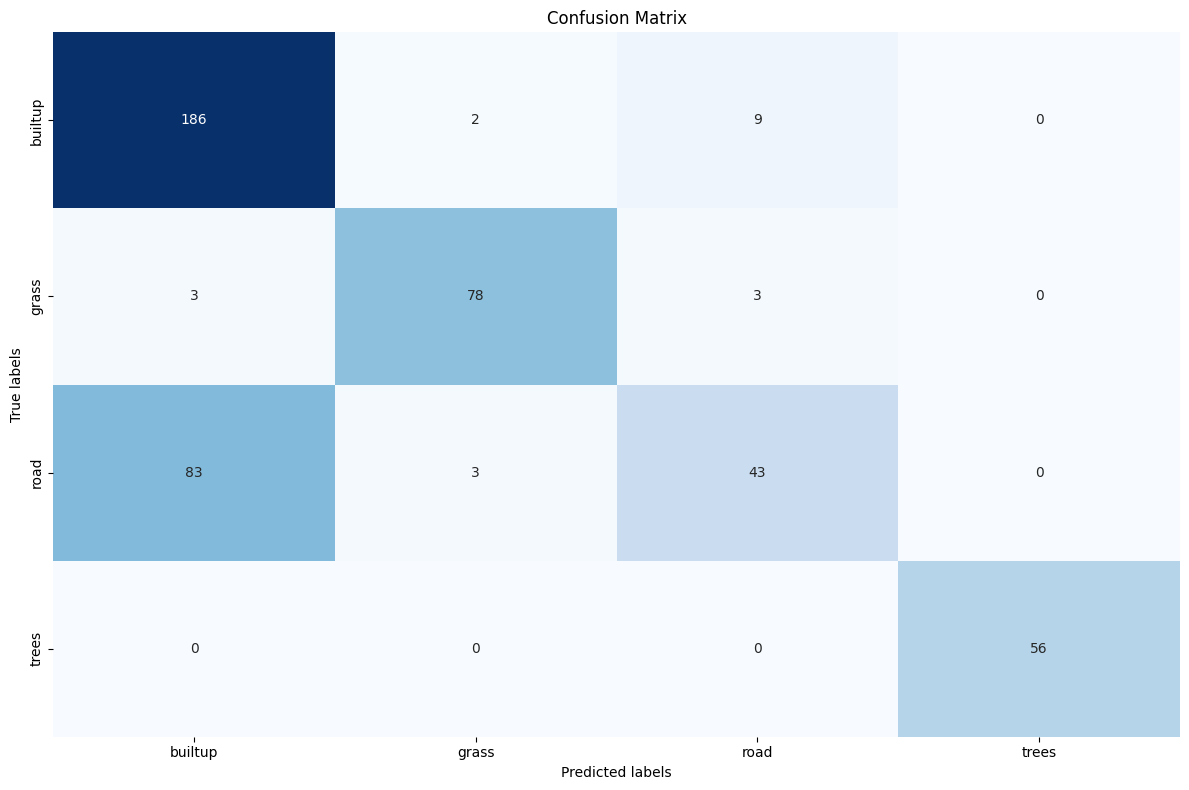

In [15]:
label_mapping = {0: "builtup", 1: "grass", 2: "road", 3: "trees"}
class_names_str = [label_mapping[label] for label in simple_model.classes_]
vis_ops.plot_confusion_matrix(y_test, simple_preds_test, class_names_str)

# True Positives (TP): 

The diagonal elements (from top left to bottom right) represent the true positives for each class.

# False Positives (FP):

These are the values in the same column but not on the diagonal. They represent instances that were incorrectly predicted as that class.

# False Negatives (FN):

These are the values in the same row but not on the diagonal. They represent instances that were incorrectly not predicted as that class.

# True Negatives (TN):

These are all the values that are not on the row or column of the current class. They represent instances that were correctly not predicted as that class.

In [17]:
# Load the our best model
with open("trained_models/cat.pkl", "rb") as file:
    stacked = pickle.load(file)

In [18]:
stacked

Pipeline(steps=[('combined_features',
                 FeatureUnion(transformer_list=[('pipeline_1',
                                                 Pipeline(steps=[('preprocessor',
                                                                  ColumnTransformer(transformers=[('numerical_transformer',
                                                                                                   Pipeline(steps=[('log_transformer',
                                                                                                                    FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                                                   ('poly_transformer',
                                                                                                                    PolynomialFeatures(include_bias=False))]),
                                                                                                   ['BLUE',
                                                                                                    'GREEN',
                                                                                                    'RED',
                                                                                                    'NIR',
                                                                                                    'SWIR',
                                                                                                    'NDVI...
                                                                                                                                  sparse_output=False),
                                                                                                                    ['NDVI_binary']),
                                                                                                                   ('ordinal_encoder',
                                                                                                                    OrdinalEncoder(categories=[['low_veg',
                                                                                                                                                'medium_veg',
                                                                                                                                                'high_veg']],
                                                                                                                                   dtype=<class 'int'>),
                                                                                                                    ['NDVI_categorized'])]))])),
                                                                 ('min_max_scaler',
                                                                  MinMaxScaler()),
                                                                 ('pca_transformer',
                                                                  PCA(n_components=7))]))])),
                ('feature_selector', SelectKBest(k=25)),
                ('model',
                 <catboost.core.CatBoostClassifier object at 0x0000022A2FE1A410>)])

In [19]:
X_train = raster_ops.indices_binary_category(X_train) 
X_test = raster_ops.indices_binary_category(X_test)
X_train.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,NDVI_categorized,NDVI_binary
0,350.0,542.0000,323.0,3277.0000,1975.3334,0.820556,-0.247826,0.002545,high_veg,veg
1,390.0,555.0000,380.0,3016.6667,1991.0000,0.776251,-0.204819,0.002227,high_veg,veg
2,1177.0,1224.6666,1268.0,1385.0000,1687.4000,0.044101,0.098425,0.000127,low_veg,non_veg
3,363.2,546.5000,395.0,3244.5000,2052.0000,0.782937,-0.225149,0.002438,high_veg,veg
4,1095.6,1107.3334,1154.0,1228.0000,1573.0000,0.031066,0.123170,0.000098,low_veg,non_veg


In [20]:
# make predictions for train and test data
stacked_preds_train = stacked.predict(X_train)
stacked_preds_test = stacked.predict(X_test)

In [21]:
# compute for the train and test data the accuracy of the stacked model
print("Stacked Model Accuracy")
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, stacked_preds_train)}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, stacked_preds_test)}")


Stacked Model Accuracy
Train Accuracy: (0.9828326180257511, 0.9829296079363253, 0.9828326180257511, 0.9828544870878537)
Test Accuracy: (0.9785407725321889, 0.9785349986728615, 0.9785407725321889, 0.9785111373932458)


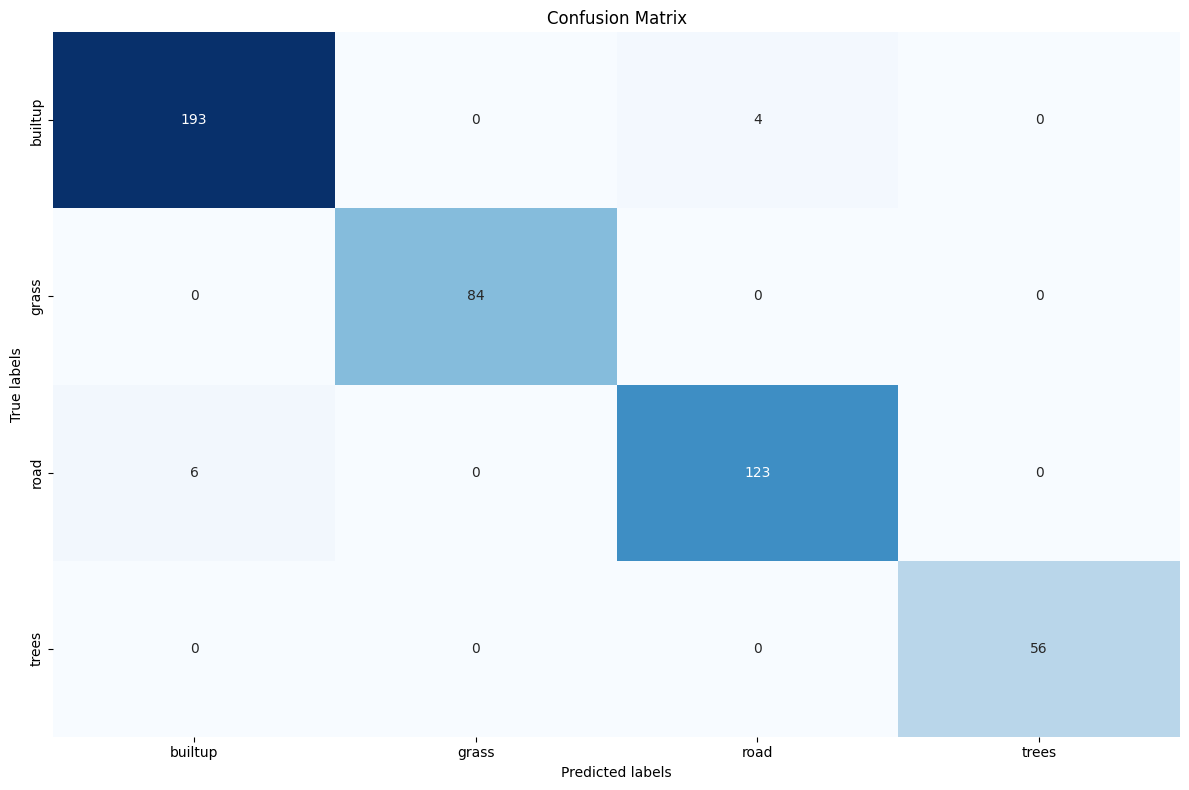

In [22]:
label_mapping = {0: "builtup", 1: "grass", 2: "road", 3: "trees"}
class_names_str = [label_mapping[label] for label in stacked.classes_]
vis_ops.plot_confusion_matrix(y_test, stacked_preds_test, class_names_str)